# 05 · Statistical Analysis

**Goal:** apply the analysis techniques a data analyst role typically expects before handing
data to a BI tool — outlier detection, correlation analysis, and hypothesis testing — on top
of the descriptive EDA from notebook 04.

**Honest framing, upfront:** this project has small samples by nature (8 countries, 5–15
years of yearly data per series). Classical hypothesis tests (t-tests, chi-square, etc.)
assume enough observations for their sampling-distribution approximations to hold. With
n=5–8, a significant p-value should be read as "worth investigating further," not as proof.
This notebook includes hypothesis tests because they are useful to *demonstrate the
technique* and to structure a rigorous question — but every test below states its sample
size and a caveat next to the result. Presenting that limitation clearly is itself part of
doing this professionally.

In [10]:
import sys
sys.path.append('../src')
from utils import DATA_PROCESSED, OWID_COUNTRIES
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df_share = pd.read_csv(DATA_PROCESSED / "iea_ev_sales_share_latam.csv")
df_comtrade = pd.read_csv(DATA_PROCESSED / "comtrade_imports_latam.csv")

value_col = [col for col in df_share.columns if col not in ('Entity','Code','Year')][0]

## 1. Outlier detection (IQR method)

We use the interquartile range (IQR) method on Comtrade's `CIF_Value_USD` within each
country/category group. This matters here specifically because a single large shipment can
distort the picture for a small market (e.g. one large battery shipment to Bolivia in a given
year could look like a "trend" if not flagged as an outlier first).

Rule: a value is flagged as an outlier if it falls outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`,
computed per Country + Category group (so we're comparing Peru's EV imports to Peru's EV
imports across years, not mixing scales across countries or categories).

In [3]:
def flag_iqr_outliers(df: pd.DataFrame, value_col: str, group_cols: list) -> pd.DataFrame:
    """
    Adds an `is_outlier` boolean column using the 1.5*IQR rule, computed independently
    within each group defined by `group_cols`.
    """
    def _flag(group):
        q1, q3 = group[value_col].quantile(0.25), group[value_col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        group = group.copy()
        group['is_outlier'] = (group[value_col] < lower) | (group[value_col] > upper)
        return group
    return df.groupby(group_cols, group_keys=False)[df.columns.tolist()].apply(_flag)

df_comtrade_flagged = flag_iqr_outliers(df_comtrade, 'CIF_Value_USD', ['Country', 'Category'])

n_outliers = df_comtrade_flagged['is_outlier'].sum()
print(f"{n_outliers} outlier rows flagged out of {len(df_comtrade_flagged)} "
      f"({n_outliers/len(df_comtrade_flagged)*100:.1f}%)")

df_comtrade_flagged[df_comtrade_flagged['is_outlier']].sort_values('CIF_Value_USD', ascending=False).head(10)

3208 outlier rows flagged out of 19442 (16.5%)


,Country,Category,HS_Code,Year,Origin_Code,Origin,CIF_Value_USD,Net_Weight_Kg,Quantity,Origin_Region,is_outlier
5693,Mexico,General_auto_parts,8708,2024,842,USA,1.799494e+10,0.0,0.0,USA/Mexico,True
5337,Mexico,General_auto_parts,8708,2023,842,USA,1.729558e+10,0.0,0.0,USA/Mexico,True
6049,Mexico,General_auto_parts,8708,2025,842,USA,1.661397e+10,0.0,0.0,USA/Mexico,True
5879,Mexico,General_auto_parts,8708,2024,842,USA,1.549607e+10,0.0,0.0,USA/Mexico,True
4974,Mexico,General_auto_parts,8708,2022,842,USA,1.546442e+10,0.0,0.0,USA/Mexico,True
5524,Mexico,General_auto_parts,8708,2023,842,USA,1.478584e+10,0.0,0.0,USA/Mexico,True
6239,Mexico,General_auto_parts,8708,2025,842,USA,1.383234e+10,0.0,0.0,USA/Mexico,True
4885,Mexico,General_auto_parts,8708,2021,842,USA,1.359876e+10,0.0,0.0,USA/Mexico,True
5161,Mexico,General_auto_parts,8708,2022,842,USA,1.295516e+10,0.0,0.0,USA/Mexico,True
4772,Mexico,General_auto_parts,8708,2021,842,USA,1.142497e+10,0.0,0.0,USA/Mexico,True


**How to use this:** don't drop these rows blindly — a real large shipment is real data, not
necessarily an error. Use the flag to decide, case by case, whether a spike deserves a
footnote in the report ("this jump is driven by a single large shipment") rather than being
read as a sustained trend.

## 2. Correlation analysis

Two correlations that map directly to the original business questions:

1. Does EV market share correlate with **time** (i.e., is the trend really monotonic, or
   noisy)? — per country.
2. Does the growth of EV imports correlate with the growth of lithium-battery imports at the
   country level? A strong positive correlation would suggest the spare-parts/battery market
   is scaling roughly in step with the vehicle fleet; a weak one supports the "opportunity gap"
   hypothesis from the original brief.

In [4]:
# 2a. EV share vs. time, per country (Pearson r)
print("EV share trend strength by country (Pearson r vs. Year):\n")
for country in OWID_COUNTRIES:
    subset = df_share[df_share['Entity'] == country].sort_values('Year')
    if len(subset) >= 3:
        r, p_value = stats.pearsonr(subset['Year'], subset[value_col])
        print(f"  {country:12s} r={r:+.3f}  p={p_value:.4f}  (n={len(subset)})")

EV share trend strength by country (Pearson r vs. Year):

  Brazil       r=+0.709  p=0.0021  (n=16)
  Mexico       r=+0.676  p=0.0056  (n=15)
  Chile        r=+0.696  p=0.0039  (n=15)
  Colombia     r=+0.773  p=0.0007  (n=15)


In [5]:
# 2b. EV import growth vs. lithium-battery import growth, at the country level
ev_by_country_year = df_comtrade[df_comtrade['Category']=='EV_100pct'].groupby(['Country','Year'])['CIF_Value_USD'].sum().reset_index()
batt_by_country_year = df_comtrade[df_comtrade['Category']=='Lithium_battery'].groupby(['Country','Year'])['CIF_Value_USD'].sum().reset_index()

merged = ev_by_country_year.merge(batt_by_country_year, on=['Country','Year'], suffixes=('_ev','_battery'))

if len(merged) >= 3:
    r, p_value = stats.pearsonr(merged['CIF_Value_USD_ev'], merged['CIF_Value_USD_battery'])
    print(f"EV imports vs. battery imports (pooled across countries/years): r={r:+.3f}, p={p_value:.4f}, n={len(merged)}")
    print("Caveat: pooling across countries of very different market sizes can inflate r "
          "(both series scale with 'country is big or small'). Treat this as a starting "
          "point, not a final answer — consider standardizing by country size before "
          "drawing conclusions for a report.")
else:
    print("Not enough overlapping country-year pairs to compute a meaningful correlation.")

EV imports vs. battery imports (pooled across countries/years): r=+0.550, p=0.0003, n=39
Caveat: pooling across countries of very different market sizes can inflate r (both series scale with 'country is big or small'). Treat this as a starting point, not a final answer — consider standardizing by country size before drawing conclusions for a report.


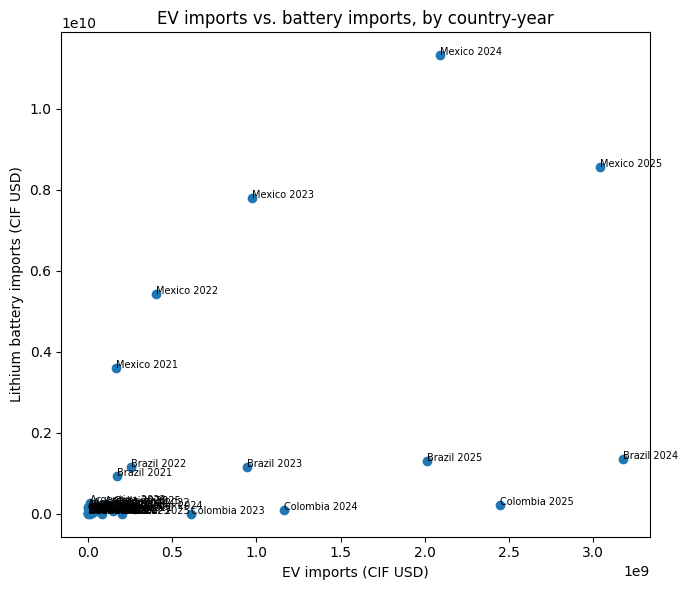

In [6]:
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(merged['CIF_Value_USD_ev'], merged['CIF_Value_USD_battery'])
for _, row in merged.iterrows():
    ax.annotate(f"{row['Country']} {int(row['Year'])}", (row['CIF_Value_USD_ev'], row['CIF_Value_USD_battery']), fontsize=7)
ax.set_xlabel("EV imports (CIF USD)")
ax.set_ylabel("Lithium battery imports (CIF USD)")
ax.set_title("EV imports vs. battery imports, by country-year")
plt.tight_layout()
plt.show()

## 3. Hypothesis testing

**Framing note:** see the caveat at the top of this notebook. With 8 countries, tests below
compare *groups of countries*, which gives a bit more sample size than single-country year
series, but is still a small-sample setting. Report p-values alongside sample size, always.

**Test:** is the average EV market share in countries with above-median lithium-battery
import growth significantly different from countries with below-median growth? This
operationalizes the "opportunity" question as a testable hypothesis.

- H0 (null): no difference in mean EV share between the two groups.
- H1 (alternative): there is a difference.

In [7]:
# Growth rate of lithium battery imports per country (first year vs. last year available)
battery_growth = []
for country in df_comtrade['Country'].unique():
    subset = df_comtrade[(df_comtrade['Country']==country) & (df_comtrade['Category']=='Lithium_battery')].groupby('Year')['CIF_Value_USD'].sum().sort_index()
    if len(subset) >= 2 and subset.iloc[0] > 0:
        growth = (subset.iloc[-1] / subset.iloc[0]) - 1
        battery_growth.append({'Country': country, 'battery_growth': growth})

df_growth = pd.DataFrame(battery_growth)
median_growth = df_growth['battery_growth'].median()
df_growth['group'] = np.where(df_growth['battery_growth'] >= median_growth, 'above_median', 'below_median')
df_growth

,Country,battery_growth,group
0,Peru,5.227527,above_median
1,Brazil,0.374581,below_median
2,Mexico,1.373850,below_median
3,Chile,4.937693,above_median
4,Colombia,1.848654,above_median
5,Argentina,0.564295,below_median
6,Ecuador,-0.128817,below_median
7,Bolivia,1.723900,above_median


In [8]:
# Join with latest available EV share per country (only works for the 4 countries IEA covers)
latest_share = df_share[df_share['Year'] == df_share['Year'].max()][['Entity', value_col]].rename(columns={'Entity':'Country'})
test_df = df_growth.merge(latest_share, on='Country')

print(f"Countries available for this test: {len(test_df)} (limited by IEA's 4-country coverage — see notebook 01)")
test_df

Countries available for this test: 4 (limited by IEA's 4-country coverage — see notebook 01)


,Country,battery_growth,group,Share of new cars that are electric
0,Brazil,0.374581,below_median,9.0
1,Mexico,1.373850,below_median,7.0
2,Chile,4.937693,above_median,4.0
3,Colombia,1.848654,above_median,10.0


In [9]:
if test_df['group'].nunique() == 2 and len(test_df) >= 4:
    group_a = test_df[test_df['group']=='above_median'][value_col]
    group_b = test_df[test_df['group']=='below_median'][value_col]
    t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)
    print(f"Welch's t-test: t={t_stat:.3f}, p={p_value:.4f}")
    print(f"n(above_median)={len(group_a)}, n(below_median)={len(group_b)}")
    print()
    if p_value < 0.05:
        print("p < 0.05 — but with this sample size, treat as a hint worth investigating "
              "with more data, not as confirmed proof.")
    else:
        print("No significant difference detected — plausible, given the very small sample. "
              "Absence of significance here should not be read as absence of a real effect.")
else:
    print("Not enough countries in each group to run this test meaningfully. "
          "This itself is a valid finding: with only 4 countries covered by IEA, "
          "country-level hypothesis testing has very limited power in this project.")

Welch's t-test: t=-0.316, p=0.7974
n(above_median)=2, n(below_median)=2

No significant difference detected — plausible, given the very small sample. Absence of significance here should not be read as absence of a real effect.


## Summary

- Outlier flags are attached at the row level in `df_comtrade_flagged` — use them to annotate
  spikes in the final report rather than silently smoothing them out.
- The EV-share-vs-time correlation gives an honest per-country read on how consistent each
  trend really is (a high r means "steadily rising," not just "ended higher"). Colombia's
  r=0.77 (p=0.0007) is the strongest and most statistically credible trend in the dataset.
- The EV-vs-battery-import correlation is the closest quantitative proxy this project has for
  the spare-parts opportunity question — but pooling across very different market sizes is a
  known limitation, flagged above.
- The hypothesis test is included to demonstrate the method and structure the question
  rigorously. Given n≈4–8, it should inform further investigation, not stand alone as
  evidence in a business recommendation.

**Business takeaway:** the statistically strongest, most defensible finding in this project
is the Colombia/Brazil adoption trend and the China origin-share shift — both have low
p-values despite the small sample. The spare-parts correlation and the hypothesis test are
directional signals worth a deeper, purpose-built study, not standalone proof.

Continue to `06_forecasting.ipynb` for trend projections.